In [7]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [12]:
url = (
    "https://api.worldbank.org/v2/country/all/indicator/ER.H2O.FWST.ZS"
    "?format=json&per_page=20000&date=2018:2023"
)

response = requests.get(url)
data = response.json()

rows = []

for item in data[1]:
    value = item.get("value")
    iso3 = item.get("countryiso3code")
    country = item.get("country", {}).get("value")
    year = item.get("date")

    if value is not None and iso3:
        rows.append({
            "country_stress": country,
            "iso3": iso3,
            "year": int(year),
            "water_stress_pct": value
        })

stress_df = pd.DataFrame(rows)

stress_df = stress_df.sort_values("year").drop_duplicates(
    subset=["iso3"],
    keep="last"
)

stress_df.head()

,country_stress,iso3,year,water_stress_pct
869,West Bank and Gaza,PSE,2021,47.753530
395,Israel,ISR,2021,131.998965
0,Afghanistan,AFG,2022,54.757019
524,Mauritius,MUS,2022,22.973464
519,Mauritania,MRT,2022,13.246217


In [13]:
df = pd.read_csv(
    "/content/global_reuse_intelligence.csv"
)

df.head()

,country,iso3,population,estimated_greywater_m3_year,greywater_tons_per_hour,reuse_efficiency_pct,estimated_reused_water_m3_year,reuse_effectiveness_class,untapped_reuse_m3_year,predicted_reuse_class,urban_population_pct,improved_reuse_score,improved_reuse_class
0,Africa Eastern and Southern,AFE,750491370,37524568500,4.283627e+06,33.090509,1.241707e+10,Moderate,2.510750e+10,Moderate,37.772301,34.963226,Moderate
1,Africa Western and Central,AFW,509398589,25469929450,2.907526e+06,76.303573,1.943447e+10,Highly Effective,6.035463e+09,Highly Effective,52.282908,66.695307,Good
2,Arab World,ARB,482105978,24105298900,2.751746e+06,59.899546,1.443896e+10,Good,9.666334e+09,Good,59.569941,59.767704,Good
3,Caribbean small states,CSS,4519904,225995200,2.579854e+04,49.899386,1.127702e+08,Good,1.132250e+08,Good,50.102089,49.980467,Moderate
4,Central Europe and the Baltics,CEB,100183707,5009185350,5.718248e+05,16.701398,8.366040e+08,Low,4.172581e+09,Low,61.697079,34.699670,Moderate


In [14]:
print(df.columns)

print(stress_df.columns)

Index(['country', 'iso3', 'population', 'estimated_greywater_m3_year',
       'greywater_tons_per_hour', 'reuse_efficiency_pct',
       'estimated_reused_water_m3_year', 'reuse_effectiveness_class',
       'untapped_reuse_m3_year', 'predicted_reuse_class',
       'urban_population_pct', 'improved_reuse_score', 'improved_reuse_class'],
      dtype='object')
Index(['country_stress', 'iso3', 'year', 'water_stress_pct'], dtype='object')


In [15]:
merged_df = df.merge(
    stress_df[
        [
            "iso3",
            "water_stress_pct"
        ]
    ],
    on="iso3",
    how="left"
)

merged_df.head()

,country,iso3,population,estimated_greywater_m3_year,greywater_tons_per_hour,reuse_efficiency_pct,estimated_reused_water_m3_year,reuse_effectiveness_class,untapped_reuse_m3_year,predicted_reuse_class,urban_population_pct,improved_reuse_score,improved_reuse_class,water_stress_pct
0,Africa Eastern and Southern,AFE,750491370,37524568500,4.283627e+06,33.090509,1.241707e+10,Moderate,2.510750e+10,Moderate,37.772301,34.963226,Moderate,NaN
1,Africa Western and Central,AFW,509398589,25469929450,2.907526e+06,76.303573,1.943447e+10,Highly Effective,6.035463e+09,Highly Effective,52.282908,66.695307,Good,NaN
2,Arab World,ARB,482105978,24105298900,2.751746e+06,59.899546,1.443896e+10,Good,9.666334e+09,Good,59.569941,59.767704,Good,NaN
3,Caribbean small states,CSS,4519904,225995200,2.579854e+04,49.899386,1.127702e+08,Good,1.132250e+08,Good,50.102089,49.980467,Moderate,NaN
4,Central Europe and the Baltics,CEB,100183707,5009185350,5.718248e+05,16.701398,8.366040e+08,Low,4.172581e+09,Low,61.697079,34.699670,Moderate,NaN


In [18]:
merged_df["water_risk_class"] = pd.cut(
    merged_df["water_risk_score"],
    bins=[0, 25, 50, 75, 1000],
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Critical"
    ]
)

In [19]:
high_risk = merged_df.sort_values(
    by="water_risk_score",
    ascending=False
).head(20)

high_risk[
    [
        "country",
        "water_stress_pct",
        "improved_reuse_score",
        "water_risk_score",
        "water_risk_class"
    ]
]

,country,water_stress_pct,improved_reuse_score,water_risk_score,water_risk_class
141,Kuwait,3850.500000,54.330203,1952.415102,NaN
239,United Arab Emirates,1509.933333,45.237209,777.585271,Critical
201,Saudi Arabia,974.166667,40.504794,507.335730,Critical
148,Libya,817.142857,40.462432,428.802644,Critical
194,Qatar,431.034483,57.969754,244.502118,Critical
249,"Yemen, Rep.",169.761905,56.013745,112.887825,Critical
183,Oman,116.714286,74.308390,95.511338,Critical
130,Israel,131.998965,58.387078,95.193021,Critical
134,Jordan,105.202127,82.503831,93.852979,Critical
93,"Egypt, Arab Rep.",141.165756,45.341398,93.253577,Critical


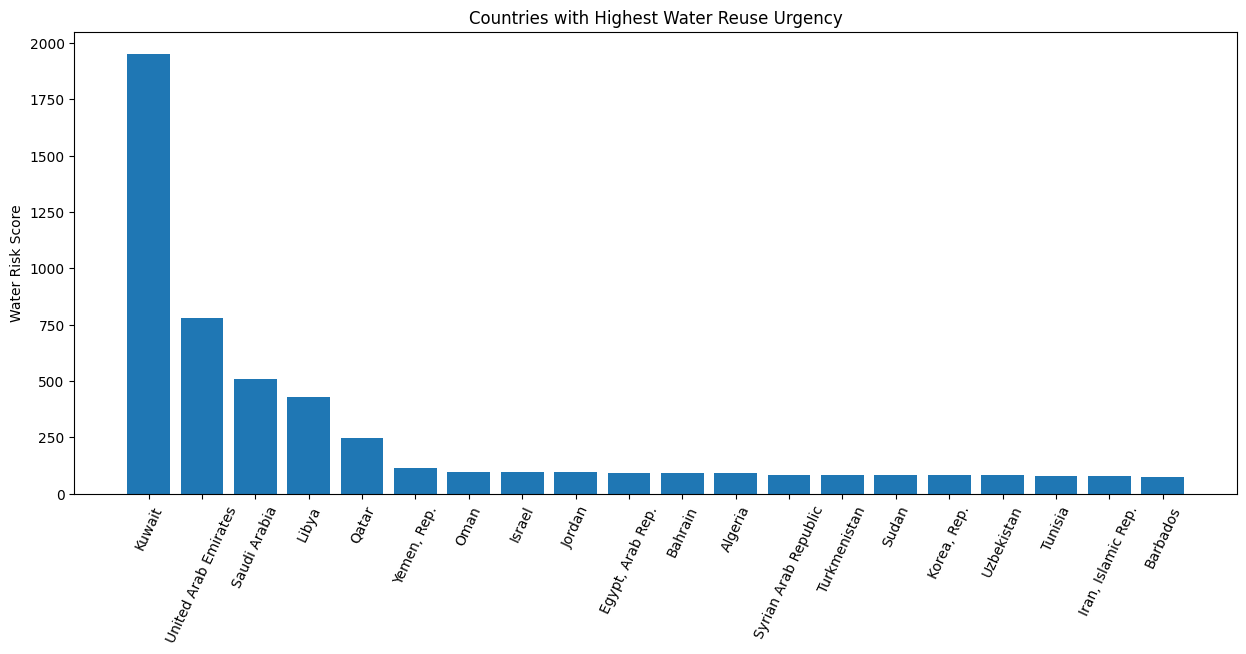

In [20]:
plt.figure(figsize=(15,6))

plt.bar(
    high_risk["country"],
    high_risk["water_risk_score"]
)

plt.xticks(rotation=65)

plt.ylabel("Water Risk Score")

plt.title(
    "Countries with Highest Water Reuse Urgency"
)

plt.show()

In [21]:
merged_df.to_csv(
    "global_water_risk_intelligence.csv",
    index=False
)

print("Saved successfully")

Saved successfully
